In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
%matplotlib inline

In [94]:
!nvidia-smi

Tue Feb 24 19:23:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P0              5W /   65W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [95]:
#from google.colab import drive
#drive.mount('/content/drive')

In [96]:
df=pd.read_csv(r"C:\Users\vivaa\OneDrive\Desktop\Personal Projects\Stock Price Predictor\Data\Raw_Data\^NSEI_daily.csv")

## The exact path for Colab
#file_path = "/content/drive/MyDrive/Colab Notebooks/^NSEI_daily.csv"
#
## Load the data
#df = pd.read_csv(file_path)
#
## Verify it loaded
#print(f"Data loaded! Shape: {df.shape}")
#df.head()

In [97]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-09-17,4494.64990234375,4494.64990234375,4549.0498046875,4482.85009765625,4518.4501953125,0
3,2007-09-18,4546.2001953125,4546.2001953125,4551.7998046875,4481.5498046875,4494.10009765625,0
4,2007-09-19,4732.35009765625,4732.35009765625,4739.0,4550.25,4550.25,0


In [98]:
df.shape

(4524, 7)

In [99]:
df.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [100]:
column=['date', 'close','close1', 'high', 'low', 'open', 'volume']
df.columns=column

In [101]:
df.drop(index=[0,1],axis=0,inplace=True)
df.drop(columns=['close1'],axis=1,inplace=True)
df.reset_index(drop=True,inplace=True)

In [102]:
df.shape

(4522, 6)

In [103]:
df.dtypes

date      object
close     object
high      object
low       object
open      object
volume    object
dtype: object

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4522 entries, 0 to 4521
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    4522 non-null   object
 1   close   4522 non-null   object
 2   high    4522 non-null   object
 3   low     4522 non-null   object
 4   open    4522 non-null   object
 5   volume  4522 non-null   object
dtypes: object(6)
memory usage: 212.1+ KB


In [105]:
df.describe()

,date,close,high,low,open,volume
count,4522,4522,4522,4522,4522,4522
unique,4522,4470,4483,4483,4481,2228
top,2007-09-17,5486.14990234375,5267.14990234375,7853.2998046875,5869.9501953125,0
freq,1,3,2,2,2,1334


In [106]:
df.isnull().sum()

date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64

In [107]:
df["date"] = pd.to_datetime(df["date"])
for i in ['close', 'high', 'low', 'open', 'volume']:
    df[i]=df[i].astype(float)

In [108]:
df["date"].min()

Timestamp('2007-09-17 00:00:00')

In [109]:
df.dtypes

date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume           float64
dtype: object

In [110]:
df.head()

,date,close,high,low,open,volume
0,2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0.0
1,2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0.0
2,2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0.0
3,2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0.0
4,2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0.0


In [111]:
df.describe()

,date,close,high,low,open,volume
count,4522,4522.000000,4522.000000,4522.000000,4522.000000,4.522000e+03
mean,2016-12-12 19:25:30.119416064,11028.401908,11092.470576,10961.462004,11034.684886,2.123987e+05
min,2007-09-17 00:00:00,2524.199951,2585.300049,2252.750000,2553.600098,0.000000e+00
25%,2012-05-02 06:00:00,5691.074829,5726.737549,5650.674805,5693.312378,0.000000e+00
50%,2016-12-22 12:00:00,8744.149902,8792.049805,8703.550293,8756.625000,1.897500e+05
75%,2021-07-27 18:00:00,15788.375244,15863.100342,15720.899902,15799.562256,2.956000e+05
max,2026-02-20 00:00:00,26328.550781,26373.199219,26210.050781,26333.699219,1.811000e+06
std,NaN,6441.130396,6462.049908,6418.805216,6443.479213,2.053813e+05


In [112]:
df.head(5)

,date,close,high,low,open,volume
0,2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0.0
1,2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0.0
2,2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0.0
3,2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0.0
4,2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0.0


In [113]:
df.dtypes

date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume           float64
dtype: object

In [114]:
import pandas as pd
import numpy as np

def add_technical_features(df):
    # 1. Create a copy to avoid SettingWithCopy warnings on the original df
    df = df.copy()
    
    # --- BASE CALCULATIONS ---
    # Daily Return (Base for volatility and mean returns)
    # calculated as: (Price_today - Price_yesterday) / Price_yesterday
    df['daily_ret'] = df['close'].pct_change()
    
    # --- 1. ROLLING MEAN RETURNS ---
    # The average daily return over the last N days
    df['roll_mean_ret_5'] = df['daily_ret'].rolling(window=5).mean()
    df['roll_mean_ret_10'] = df['daily_ret'].rolling(window=10).mean()
    df['roll_mean_ret_20'] = df['daily_ret'].rolling(window=20).mean()

    # --- 2. ROLLING VOLATILITY ---
    # Standard deviation of daily returns (Risk)
    df['roll_vol_5'] = df['daily_ret'].rolling(window=5).std()
    df['roll_vol_10'] = df['daily_ret'].rolling(window=10).std()
    df['roll_vol_20'] = df['daily_ret'].rolling(window=20).std()
    
    # --- 3. MOMENTUM (CUMULATIVE RETURN) ---
    # Total percentage change over the last 10 days
    # Formula: (Price_today - Price_10_days_ago) / Price_10_days_ago
    df['momentum_10'] = df['close'].pct_change(periods=10)
    
    # --- 4. VOLUME CHANGE ---
    # Daily percentage change in volume
    #df['vol_change'] = df['volume'].pct_change()
    
    # --- 5. VOLUME ROLLING MEAN ---
    # Average volume over the last 5 days
    df['vol_roll_mean_5'] = df['volume'].rolling(window=5).mean()
    
    # --- 6. MOVING AVERAGE DIFFERENCE (DIVERGENCE) ---
    # How far the current price is from the 10-day moving average
    # Logic: (Price - MA) / MA
    ma_10 = df['close'].rolling(window=10).mean()
    df['ma_diff_10'] = (df['close'] - ma_10) / ma_10
    return df

# --- EXAMPLE USAGE ---
# Assuming you have a dataframe 'df' with 'close' and 'volume' columns:
df = add_technical_features(df)


In [115]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'daily_ret',
       'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_mean_ret_20', 'roll_vol_5',
       'roll_vol_10', 'roll_vol_20', 'momentum_10', 'vol_roll_mean_5',
       'ma_diff_10'],
      dtype='object')

In [116]:
df.tail()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_mean_ret_20,roll_vol_5,roll_vol_10,roll_vol_20,momentum_10,vol_roll_mean_5,ma_diff_10
4517,2026-02-16,25682.750000,25697.000000,25372.699219,25423.599609,275800.0,0.008309,-0.001404,0.002391,0.000015,0.008187,0.010272,0.008946,0.023690,388200.0,-0.002834
4518,2026-02-17,25725.400391,25764.400391,25570.300781,25637.949219,344100.0,0.001661,-0.001597,0.000010,0.000310,0.008080,0.006330,0.008895,-0.000084,364840.0,-0.001170
4519,2026-02-18,25819.349609,25828.050781,25645.150391,25752.650391,310200.0,0.003652,-0.001010,0.000187,0.001183,0.008390,0.006412,0.008273,0.001682,360600.0,0.002309
4520,2026-02-19,25454.349609,25885.300781,25388.750000,25873.349609,298200.0,-0.014137,-0.002708,-0.000710,0.000624,0.010222,0.007735,0.008919,-0.007349,336360.0,-0.011137
4521,2026-02-20,25571.250000,25663.550781,25379.750000,25406.550781,0.0,0.004593,0.000816,-0.000450,0.000591,0.008700,0.007879,0.008902,-0.004766,245660.0,-0.006122


Consider walk-forward validation (train on years 1-5, test on year 6, then train on 2-6, test on 7, etc.)

#Backtesting

In [117]:
df["log_volume"] = np.log(df["volume"] + 1)

In [118]:
df.shape

(4522, 17)

In [119]:
for h in range(1, 21):
    df[f"target_{h}"] = (df["close"].shift(-h) > df["close"]).astype(int)

In [120]:
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

In [121]:
df.dtypes

date                datetime64[ns]
close                      float64
high                       float64
low                        float64
open                       float64
volume                     float64
daily_ret                  float64
roll_mean_ret_5            float64
roll_mean_ret_10           float64
roll_mean_ret_20           float64
roll_vol_5                 float64
roll_vol_10                float64
roll_vol_20                float64
momentum_10                float64
vol_roll_mean_5            float64
ma_diff_10                 float64
log_volume                 float64
target_1                     int64
target_2                     int64
target_3                     int64
target_4                     int64
target_5                     int64
target_6                     int64
target_7                     int64
target_8                     int64
target_9                     int64
target_10                    int64
target_11                    int64
target_12           

In [122]:
df.head()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_mean_ret_20,...,target_11,target_12,target_13,target_14,target_15,target_16,target_17,target_18,target_19,target_20
0,2007-10-16,5668.049805,5708.350098,5578.450195,5670.649902,0.0,-0.000414,0.012695,0.011486,0.011824,...,1,1,1,1,1,1,1,0,1,1
1,2007-10-17,5559.299805,5658.899902,5107.299805,5658.899902,0.0,-0.019186,0.004570,0.006769,0.010292,...,1,1,1,1,1,1,1,1,1,1
2,2007-10-18,5351.000000,5736.799805,5269.649902,5551.100098,0.0,-0.037469,-0.005989,0.003063,0.006371,...,1,1,1,1,1,1,1,1,1,1
3,2007-10-19,5215.299805,5390.850098,5101.750000,5360.350098,0.0,-0.025360,-0.007564,0.000965,0.004942,...,1,1,1,1,1,1,1,1,1,1
4,2007-10-22,5184.000000,5247.399902,5070.899902,5202.750000,0.0,-0.006002,-0.017686,0.002308,0.003694,...,1,1,1,1,1,1,1,1,1,1


In [123]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'daily_ret',
       'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_mean_ret_20', 'roll_vol_5',
       'roll_vol_10', 'roll_vol_20', 'momentum_10', 'vol_roll_mean_5',
       'ma_diff_10', 'log_volume', 'target_1', 'target_2', 'target_3',
       'target_4', 'target_5', 'target_6', 'target_7', 'target_8', 'target_9',
       'target_10', 'target_11', 'target_12', 'target_13', 'target_14',
       'target_15', 'target_16', 'target_17', 'target_18', 'target_19',
       'target_20'],
      dtype='object')

In [124]:
feature_cols = ['close', 'high', 'low', 'open', 'volume', 'daily_ret',
       'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_mean_ret_20', 'roll_vol_5',
       'roll_vol_10', 'roll_vol_20', 'momentum_10', 'log_volume',
       'vol_roll_mean_5', 'ma_diff_10'
]


In [125]:
lookback=60
X_list=list()
y_list=list()

In [126]:
df.columns
indices=[]

In [127]:
for t in range(lookback, len(df) - 20):
    X_t = df[feature_cols].iloc[t-lookback:t]
    X_list.append(X_t)
    y_t = df[['target_1', 'target_2', 'target_3',
       'target_4', 'target_5', 'target_6', 'target_7', 'target_8', 'target_9',
       'target_10', 'target_11', 'target_12', 'target_13', 'target_14',
       'target_15', 'target_16', 'target_17', 'target_18', 'target_19',
       'target_20']].iloc[t]
    y_list.append(y_t)
    indices.append(t)

In [128]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [129]:
X = np.array(X_list)   # shape: (num_samples, 60, num_features)
y = np.array(y_list)   # shape: (num_samples,)


In [130]:
def normalize_array(data):

    data = np.array(data)
    
    mean_val = np.mean(data)
    std_val = np.std(data)
    
    # Check for zero standard deviation to avoid division by zero
    if std_val == 0:
        return np.zeros(data.shape)
        
    standardized = (data - mean_val) / std_val
    return standardized

In [131]:
#X=normalize_array(X)

In [132]:
print(X.shape)
print(y.shape)
print(y.mean())
type(X)

(4422, 60, 16)
(4422, 20)
0.5742311171415649


numpy.ndarray

In [133]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [134]:
print(np.isinf(df[feature_cols]).sum().sum())
print(np.isnan(df[feature_cols]).sum().sum())

0
0


In [135]:
train_end = int(0.7 * len(X))
val_end   = int(0.85 * len(X))

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]
indices_train = indices[:train_end]
indices_val   = indices[train_end:val_end]
indices_test  = indices[val_end:]

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape train to 2D
X_train_2d = X_train.reshape(-1, X_train.shape[-1])

# fit ONLY on training data
scaler.fit(X_train_2d)

# transform train
X_train = scaler.transform(X_train_2d).reshape(X_train.shape)

# transform val
X_val = scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

# transform test
X_test = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

print("Post-scaling mean:", np.mean(X_train))
print("Post-scaling std:", np.std(X_train))

Post-scaling mean: -2.2803485899056294e-14
Post-scaling std: 1.0000000000000007


In [137]:
#for i in range(0,19):
#    print(y[:,i].mean())

In [138]:
print(np.mean(X_train))
np.std(X_train)

-2.2803485899056294e-14


np.float64(1.0000000000000007)

In [139]:
print(X_train.shape)
print(y_train.shape)

(3095, 60, 16)
(3095, 20)


In [140]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [141]:
LOOKBACK = 60
NUM_FEATURES = 16
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
NUM_HORIZONS = 20
batch_size=32

In [142]:
def positional_encoding(length, d_model):
    positions = np.arange(length)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates
    
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

In [143]:
inputs = tf.keras.Input(shape=(LOOKBACK, NUM_FEATURES))

embedding = tf.keras.layers.Dense(D_MODEL)
x = embedding(inputs)

pos_encoding = positional_encoding(LOOKBACK, D_MODEL)
x = x + pos_encoding
attention_layer = tf.keras.layers.MultiHeadAttention(num_heads=4,key_dim=D_MODEL // 4,dropout=0.1)

In [144]:
#def transformer_encoder_block(x):
#    attn_output, attn_scores = attention_layer(x, x, return_attention_scores=True)
#    x=x+attn_output
#    normalizer = tf.keras.layers.LayerNormalization(epsilon=1e-6)
#    x=normalizer(x)
#    ffn = tf.keras.layers.Dense(128, activation='relu')(x)
#    ffn = tf.keras.layers.Dense(D_MODEL)(ffn)
#    x=ffn+x
#    x=normalizer(x)
#    return x,attn_scores
def transformer_encoder_block(x):
    
    # Multi-head attention
    attention_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=D_MODEL // NUM_HEADS,
        dropout=0.1
    )
    
    attn_output, attn_scores = attention_layer(
        x, x, return_attention_scores=True
    )
    
    x = tf.keras.layers.Add()([x, attn_output])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Feed Forward
    ffn = tf.keras.layers.Dense(FF_DIM, activation='relu')(x)
    ffn = tf.keras.layers.Dense(D_MODEL)(ffn)
    
    x = tf.keras.layers.Add()([x, ffn])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    
    return x, attn_scores


In [145]:
'''for _ in range(2):
    x,attn_scores = transformer_encoder_block(x)'''
# First block
x, _ = transformer_encoder_block(x)

# Second block (capture attention)
x, attn_scores = transformer_encoder_block(x)

In [146]:
attn_scores.shape

(None, 4, 60, 60)

In [147]:
print(x.shape)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x.shape

(None, 60, 64)


(None, 64)

In [148]:
outputs = tf.keras.layers.Dense(20)(x)

In [149]:
'''model = tf.keras.Model(inputs=inputs,outputs=[outputs])
attention_model = tf.keras.Model(
    inputs=inputs,
    outputs=attn_scores
)'''
model = tf.keras.Model(inputs=inputs, outputs=outputs)

attention_model = tf.keras.Model(
    inputs=inputs,
    outputs=attn_scores
)

In [150]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.AUC()]
)


In [151]:
print("Unique values in y_train:", np.unique(y_train))
print("Min:", y_train.min(), "Max:", y_train.max())
print("dtype:", y_train.dtype)

Unique values in y_train: [0 1]
Min: 0 Max: 1
dtype: int64


In [152]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 64)    │      1,088 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 60, 64)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 60, 64),  │     16,640 │ add_5[0][0],      │
│ (MultiHeadAttentio… │ (None, 4, 60,     │            │ add_5[0][0]       │
│                     │ 60)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 60, 64)    │          0 │ add_5[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 60, 64)    │      8,256 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 60, 64),  │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │ (None, 4, 60,     │            │ layer_normalizat… │
│                     │ 60)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 60, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 69,332 (270.83 KB)

 Trainable params: 69,332 (270.83 KB)

 Non-trainable params: 0 (0.00 B)

In [153]:
print(np.isnan(X_train).sum())
print(np.isinf(X_train).sum())
print(np.max(np.abs(X_train)))

0
0
12.358693463657891


In [154]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=7,
    restore_best_weights=True
)

In [155]:
baseline = np.maximum(
    y_train.mean(axis=0),
    1 - y_train.mean(axis=0)
)
print(baseline[:5])

[0.52245557 0.52859451 0.53990307 0.54313409 0.55638126]


In [156]:
for layer in model.layers:
    print(layer.name)

input_layer_1
dense_6
multi_head_attention_4
add_6
layer_normalization_4
dense_7
dense_8
add_7
layer_normalization_5
multi_head_attention_5
add_8
layer_normalization_6
dense_9
dense_10
add_9
layer_normalization_7
global_average_pooling1d_1
dense_11


In [157]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - auc_1: 0.5051 - loss: 0.7323 - val_auc_1: 0.5190 - val_loss: 0.6923
Epoch 2/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - auc_1: 0.5347 - loss: 0.6837 - val_auc_1: 0.5316 - val_loss: 0.6854
Epoch 3/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - auc_1: 0.5528 - loss: 0.6800 - val_auc_1: 0.5398 - val_loss: 0.6993
Epoch 4/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - auc_1: 0.5679 - loss: 0.6770 - val_auc_1: 0.5421 - val_loss: 0.7201
Epoch 5/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_1: 0.5774 - loss: 0.6743 - val_auc_1: 0.5436 - val_loss: 0.7340
Epoch 6/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_1: 0.5900 - loss: 0.6714 - val_auc_1: 0.5399 - val_loss: 0.7681
Epoch 7/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_1: 0.6012 - loss: 0.6677 - val_auc_1: 0.5417 - val_loss: 0.7725
Epoch 8/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_1: 0.6132 - loss: 0.6628 - val_auc_1: 0.5511 - val_loss: 0.7580
Epoch 9/40
97/97 ━━━━━━━━━━━━━━━

In [158]:
attn_val = attention_model.predict(X_val)
print(attn_val.shape)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
(663, 4, 60, 60)


In [159]:
import numpy as np
from sklearn.metrics import roc_auc_score

logits = model.predict(X_val)
probs = tf.sigmoid(logits).numpy()
for h in [0, 4, 9, 19]:  # horizons 1,5,10,20
    auc = roc_auc_score(y_val[:, h], probs[:, h])
    print(f"Horizon {h+1} AUC:", auc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Horizon 1 AUC: 0.5708045006516033
Horizon 5 AUC: 0.5510413721609652
Horizon 10 AUC: 0.5787698146479845
Horizon 20 AUC: 0.31670721816707215


In [160]:
avg_attention = np.mean(attn_val, axis=(0,1,2))

In [161]:
auc_per_horizon = []

for h in range(20):
    auc = roc_auc_score(y_val[:, h], probs[:, h])
    auc_per_horizon.append(auc)

print(auc_per_horizon)

[0.5708045006516033, 0.48618017375640327, 0.4272910035181772, 0.6045342905724542, 0.5510413721609652, 0.446778764405819, 0.563145476347039, 0.605261626215005, 0.4526457277685375, 0.5787698146479845, 0.6097175359105369, 0.5754139152071968, 0.6596562597321707, 0.5643844281305705, 0.6985779825246046, 0.6587301587301587, 0.4663593155893536, 0.6200227860811802, 0.6103063474258307, 0.31670721816707215]


In [162]:
accuracy_per_horizon = []
baseline_per_horizon = []

for h in range(20):
    preds = (probs[:, h] > 0.5).astype(int)
    acc = np.mean(preds == y_val[:, h])
    accuracy_per_horizon.append(acc)
    
    p_up = np.mean(y_val[:, h])
    baseline = max(p_up, 1 - p_up)
    baseline_per_horizon.append(baseline)

for h in [0,4,9,19]:
    print(f"Horizon {h+1}")
    print("Model acc:", accuracy_per_horizon[h])
    print("Baseline acc:", baseline_per_horizon[h])

Horizon 1
Model acc: 0.5082956259426847
Baseline acc: 0.5460030165912518
Horizon 5
Model acc: 0.6018099547511312
Baseline acc: 0.5927601809954751
Horizon 10
Model acc: 0.46907993966817496
Baseline acc: 0.6123680241327301
Horizon 20
Model acc: 0.6199095022624435
Baseline acc: 0.6199095022624435


In [163]:
df["future_return_20"] = np.log(df["close"].shift(-20) / df["close"])
df['future_return_20'].isna().sum()

np.int64(20)

In [164]:
t

4481

In [165]:
df.iloc[t]["future_return_20"]

np.float64(0.011063551532957802)

In [166]:
indices_val[:5]

[3155, 3156, 3157, 3158, 3159]

In [167]:
future_returns_20_val = df.iloc[indices_val]["future_return_20"].values

In [168]:
probs_val = tf.sigmoid(model.predict(X_val)).numpy()

threshold = 0.72

signals = (probs_val[:,19] > threshold).astype(int)

strategy_returns = signals * future_returns_20_val

mean_ret = np.mean(strategy_returns)
std_ret = np.std(strategy_returns)

sharpe = mean_ret / std_ret if std_ret != 0 else 0

print("Mean return:", mean_ret)
print("Sharpe:", sharpe)
print("Trade frequency:", signals.mean())

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Mean return: 0.0021105480615501815
Sharpe: 0.06203203281361934
Trade frequency: 0.6455505279034691


In [169]:
import numpy as np

p = probs_val[:,19]

print("Min:", p.min())
print("Max:", p.max())
print("Mean:", p.mean())
print("Percentiles:", np.percentile(p, [50, 60, 70, 80, 90, 95]))

Min: 0.5457787
Max: 0.76518714
Mean: 0.7042771
Percentiles: [0.73909611 0.74586654 0.7489652  0.75179297 0.7552748  0.7597826 ]


In [170]:
thresholds = np.linspace(0.5, 0.8, 50)

for th in thresholds:
    signals = (p > th).astype(int)
    if signals.mean() == 0:
        continue
    
    strat = signals * future_returns_20_val
    sharpe = np.mean(strat) / np.std(strat)
    
    print(f"Threshold {th:.2f} | Sharpe {sharpe:.3f} | Trade freq {signals.mean():.2f}")

Threshold 0.50 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.51 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.51 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.52 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.52 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.53 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.54 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.54 | Sharpe 0.342 | Trade freq 1.00
Threshold 0.55 | Sharpe 0.332 | Trade freq 0.99
Threshold 0.56 | Sharpe 0.316 | Trade freq 0.98
Threshold 0.56 | Sharpe 0.294 | Trade freq 0.96
Threshold 0.57 | Sharpe 0.269 | Trade freq 0.94
Threshold 0.57 | Sharpe 0.231 | Trade freq 0.91
Threshold 0.58 | Sharpe 0.207 | Trade freq 0.89
Threshold 0.59 | Sharpe 0.202 | Trade freq 0.89
Threshold 0.59 | Sharpe 0.203 | Trade freq 0.88
Threshold 0.60 | Sharpe 0.200 | Trade freq 0.88
Threshold 0.60 | Sharpe 0.185 | Trade freq 0.87
Threshold 0.61 | Sharpe 0.170 | Trade freq 0.86
Threshold 0.62 | Sharpe 0.174 | Trade freq 0.84
Threshold 0.62 | Sharpe 0.174 | Trade fr

In [171]:
p = probs_val[:,19]

# find 80th percentile
threshold = np.percentile(p, 80)

signals = (p > threshold).astype(int)

strat = signals * future_returns_20_val

sharpe = np.mean(strat) / np.std(strat)

print("Top 20% threshold:", threshold)
print("Sharpe:", sharpe)
print("Trade freq:", signals.mean())

Top 20% threshold: 0.75179297
Sharpe: 0.02410827249441177
Trade freq: 0.20060331825037708


In [172]:
threshold = np.percentile(p, 90)
signals = (p > threshold).astype(int)

strat = signals * future_returns_20_val

sharpe = np.mean(strat) / np.std(strat)

print("Top 20% threshold:", threshold)
print("Sharpe:", sharpe)
print("Trade freq:", signals.mean())

Top 20% threshold: 0.7552748
Sharpe: 0.008752846939166404
Trade freq: 0.10105580693815988


In [173]:
avg_attention = np.mean(attn_val, axis=(0,1,2))

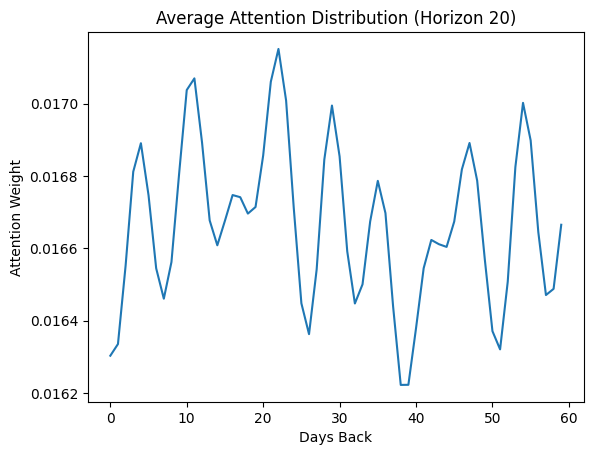

In [174]:
import matplotlib.pyplot as plt

plt.plot(avg_attention)
plt.title("Average Attention Distribution (Horizon 20)")
plt.xlabel("Days Back")
plt.ylabel("Attention Weight")
plt.show()

In [175]:
from scipy.stats import spearmanr, pearsonr

r = future_returns_20_val
p = probs_val[:,19]

print("Pearson:", pearsonr(p, r))
print("Spearman:", spearmanr(p, r))

Pearson: PearsonRResult(statistic=np.float64(-0.3746814908522567), pvalue=np.float64(1.589840939063765e-23))
Spearman: SignificanceResult(statistic=np.float64(-0.32391325222147355), pvalue=np.float64(1.1646682134014835e-17))


In [176]:
import pandas as pd

df_eval = pd.DataFrame({"p": p, "r": r})
df_eval["decile"] = pd.qcut(df_eval["p"], 10, labels=False)

print(df_eval.groupby("decile")["r"].mean())


decile
0    0.062707
1    0.010718
2    0.024107
3    0.038686
4    0.000400
5   -0.020003
6    0.007175
7    0.017307
8    0.003558
9    0.000945
Name: r, dtype: float64


In [177]:
high = p >= np.percentile(p, 80)
low  = p <= np.percentile(p, 20)

long_ret  = r[high]
short_ret = -r[low]

combined = np.concatenate([long_ret, short_ret])

print("Long-Short Sharpe:", combined.mean()/combined.std())

Long-Short Sharpe: -0.3804787714705729


In [178]:
r_ls = combined[::20]
print("Non-overlapping Sharpe:", r_ls.mean()/r_ls.std())

Non-overlapping Sharpe: -0.3424661569188518


In [179]:
future_returns_20_val.mean()

np.float64(0.014590757138840449)

In [180]:
# Get raw logits from model
logits_test = model.predict(X_test, verbose=0)

print("Logits shape:", logits_test.shape)

Logits shape: (664, 20)


In [182]:
import numpy as np

close_prices = df["close"].values

future_returns_test = []

for t in indices_test:
    r = np.log(close_prices[t + 20] / close_prices[t])
    future_returns_test.append(r)

future_returns_test = np.array(future_returns_test)

print("Future returns shape:", future_returns_test.shape)
print("Example:", future_returns_test[:5])

Future returns shape: (664,)
Example: [0.03032171 0.03363048 0.02379668 0.02522416 0.03077327]


In [183]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# logits for horizon 20
scores = logits_test[:, 19]  # index 19 = horizon 20

# actual 20-day forward log returns
returns = future_returns_test  # must be aligned

# remove any nan just in case
mask = ~np.isnan(scores) & ~np.isnan(returns)
scores = scores[mask]
returns = returns[mask]

ic, p_value = spearmanr(scores, returns)

print("Information Coefficient (Spearman):", ic)
print("p-value:", p_value)

Information Coefficient (Spearman): -0.2597092824740257
p-value: 1.071236489860963e-11


In [184]:
import numpy as np

scores = logits_test[:, 19]
returns = future_returns_test

positions = np.sign(scores)

strategy_returns = positions * returns

mean_ret = np.mean(strategy_returns)
std_ret = np.std(strategy_returns)

sharpe = mean_ret / std_ret * np.sqrt(252/20)

print("Sharpe (sign strategy):", sharpe)

Sharpe (sign strategy): 1.15229700363657


In [185]:
import numpy as np

scores = logits_test[:, 19]
returns = future_returns_test

upper = np.percentile(scores, 70)
lower = np.percentile(scores, 30)

positions = np.zeros_like(scores)

positions[scores >= upper] = 1
positions[scores <= lower] = -1

strategy_returns = positions * returns

mean_ret = np.mean(strategy_returns)
std_ret = np.std(strategy_returns)

sharpe = mean_ret / std_ret * np.sqrt(252/20)

print("Sharpe (30% quantile strategy):", sharpe)
print("Average exposure:", np.mean(np.abs(positions)))

Sharpe (30% quantile strategy): -0.9318913059718027
Average exposure: 0.5993976


In [198]:
import pandas as pd
import numpy as np

scores = logits_test[:, 19]
positions = np.sign(scores)
strategy_returns = positions * future_returns_test
#print(df.dtypes)
#dates_test = df.iloc[indices_test].index  # assumes datetime index
dates_test = df.iloc[indices_test]["date"]
results = pd.DataFrame({
    "date": dates_test,
    "strategy_return": strategy_returns
})
results["year"] = results["date"].dt.year
yearly_sharpe = results.groupby("year")["strategy_return"].apply(
    lambda x: np.mean(x) / np.std(x) * np.sqrt(252/20)
)

print(yearly_sharpe)

year
2023    2.247525
2024    0.720751
2025    0.997677
2026   -0.842491
Name: strategy_return, dtype: float64


In [199]:
df["realized_vol_20"] = df["daily_ret"].rolling(20).std()
df["realized_vol_252"] = df["daily_ret"].rolling(252).std()

df["vol_regime_percentile"] = (
    df["realized_vol_252"]
    .rolling(252)
    .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1])
)

In [200]:
df.dropna(inplace=True)